In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df=pd.read_csv('Placement (1).csv')
df.sample(5)

,Student_ID,CGPA,IQ,Placement
34,35,4.8,163,0
54,55,6.4,141,1
95,96,4.3,200,0
81,82,5.4,107,0
77,78,7.3,50,1


In [28]:
# taking the desired numeric columns
df=df[['CGPA', 'IQ', 'Placement']]
df.sample(5)

,CGPA,IQ,Placement
7,5.0,63,0
50,3.5,233,0
71,6.1,132,1
73,4.9,61,0
74,6.7,154,1


<Axes: xlabel='CGPA', ylabel='Density'>

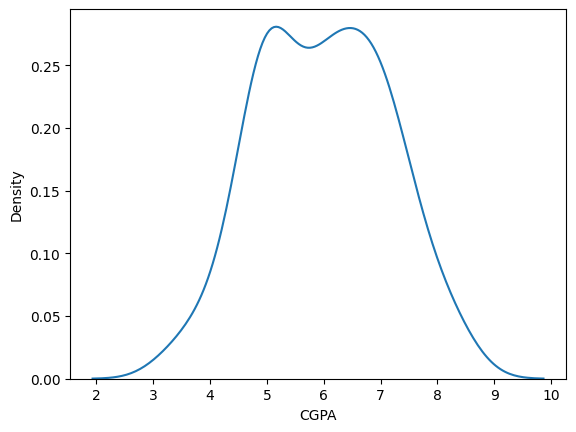

In [29]:
sns.kdeplot(df['CGPA'])

<Axes: xlabel='IQ', ylabel='Density'>

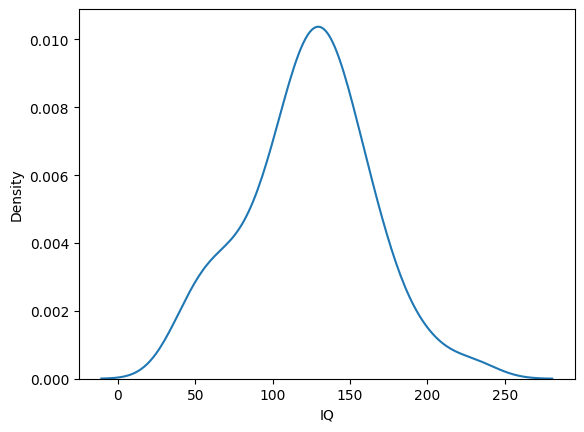

In [30]:
sns.kdeplot(df['IQ'])

<Axes: xlabel='Placement', ylabel='Density'>

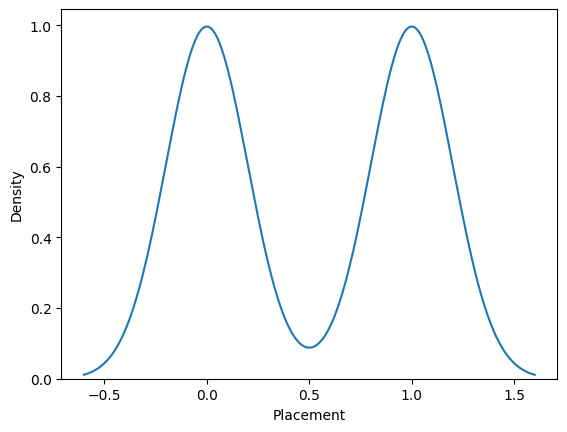

In [32]:
sns.kdeplot(df['Placement'])

<Axes: xlabel='CGPA', ylabel='IQ'>

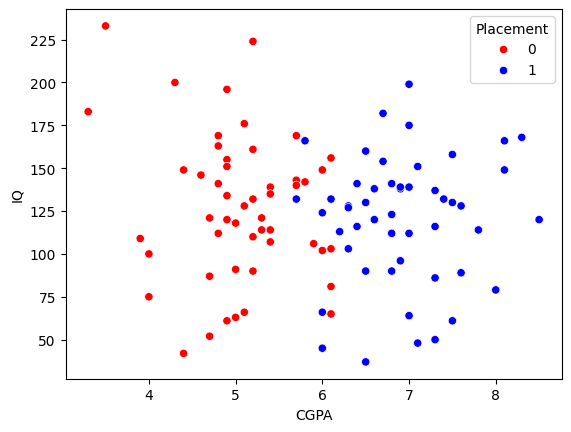

In [34]:
color_dict = {0:'red', 1:'blue'}
sns.scatterplot(x=df['CGPA'], y=df['IQ'], hue=df['Placement'], palette=color_dict)

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop('Placement',axis=1),
                                               df['Placement'],test_size=0.3,
                                               random_state=0)

X_train.shape,X_test.shape

((70, 2), (30, 2))

# Applying MinMaxScaler

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler= MinMaxScaler()

#fit the scaler to the train set,it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [42]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [43]:
np.round(X_train.describe(),1)

,CGPA,IQ
count,70.0,70.0
mean,6.0,121.7
std,1.2,39.3
min,3.3,42.0
25%,5.0,92.2
50%,6.0,125.5
75%,7.0,148.2
max,8.5,233.0


In [44]:
np.round(X_train_scaled.describe(),1)

,CGPA,IQ
count,70.0,70.0
mean,0.5,0.4
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.3
50%,0.5,0.4
75%,0.7,0.6
max,1.0,1.0


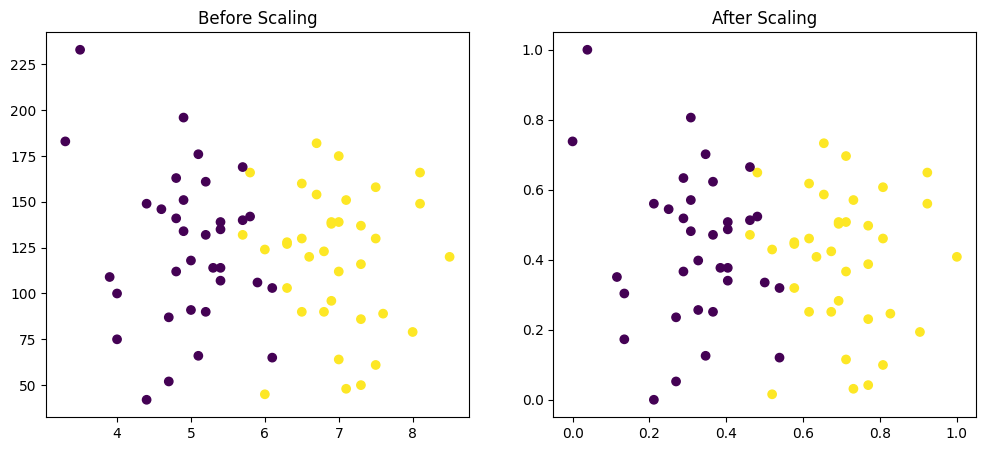

In [45]:
fig, (ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(X_train['CGPA'],X_train['IQ'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['CGPA'],X_train_scaled['IQ'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

# c=y_train : Colors each point according to its Class label value (1, 2, 3).

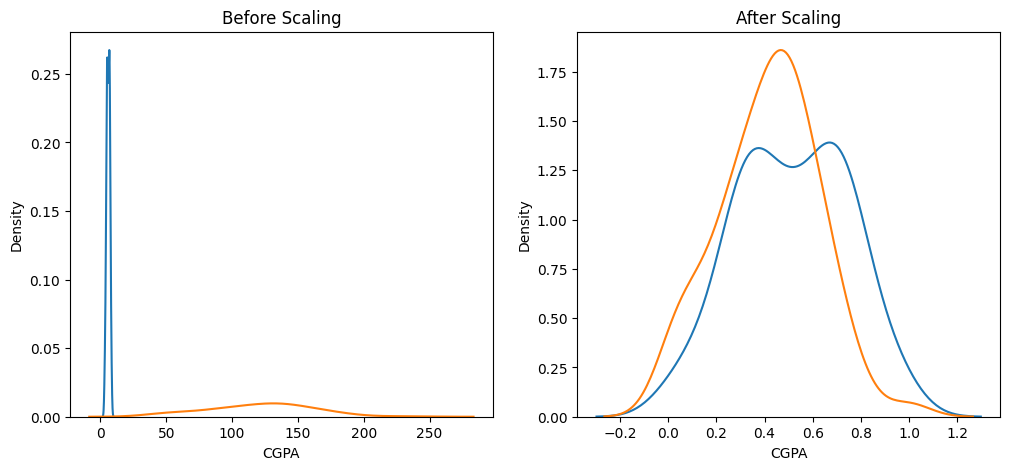

In [46]:
fig, (ax1,ax2)= plt.subplots(ncols=2,figsize=(12,5))

# befpre scaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['CGPA'],ax=ax1)
sns.kdeplot(X_train['IQ'],ax=ax1)

# after scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['CGPA'],ax=ax2)
sns.kdeplot(X_train_scaled['IQ'],ax=ax2)
plt.show()

In [49]:
X_train_scaled

,CGPA,IQ
0,0.692308,0.507853
1,0.307692,0.806283
2,0.769231,0.230366
3,0.134615,0.172775
4,0.288462,0.518325
...,...,...
65,0.211538,0.000000
66,0.326923,0.397906
67,0.711538,0.115183
68,0.365385,0.623037
